In [49]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

plt.rcParams['figure.dpi'] = 600

@njit
def oblique_shock(M1, theta_s, gamma=1.4):
    delta = np.arctan(
        2/np.tan(theta_s)
        * (M1**2*np.sin(theta_s)**2 - 1)
        / (M1**2*(gamma + np.cos(2*theta_s)) + 2)
    )

    num = (gamma-1)/2*M1**2*np.sin(theta_s)**2 + 1
    den = gamma*M1**2*np.sin(theta_s)**2 - (gamma-1)/2

    M2 = 1/np.sin(theta_s - delta)*np.sqrt(num/den)

    return delta, M2

@njit
def barV_to_barVcomps(barV, theta_s, delta):
    barVr = barV*np.cos(theta_s - delta)
    barVt = -barV*np.sin(theta_s - delta)

    W = np.empty(2)
    W[0] = barVr
    W[1] = barVt

    return W

@njit
def M_to_barV(M, gamma=1.4):
    return (2/((gamma-1)*M**2) + 1)**(-0.5)

@njit
def dWdtheta(theta, W, gamma):
    barVr = W[0]
    barVt = W[1]

    num = barVr*barVt**2 \
        - (gamma-1)*(1 - barVr**2 - barVt**2)*(2*barVr + barVt/np.tan(theta))/2

    den = (gamma-1)*(1 - barVr**2 - barVt**2)/2 - barVt**2

    dW = np.empty(2)

    dW[0] = barVt
    dW[1] = num/den

    return dW

@njit
def rk45_step(theta, W, h, gamma):
    k1 = dWdtheta(theta, W, gamma)
    k2 = dWdtheta(theta + h*(1/5), W + h*(1/5)*k1, gamma)
    k3 = dWdtheta(theta + h*(3/10), W + h*(3/40)*k1 + h*(9/40)*k2, gamma)
    k4 = dWdtheta(theta + h*(4/5), W + h*(44/45)*k1 - h*(56/15)*k2 + h*(32/9)*k3, gamma)
    k5 = dWdtheta(theta + h*(8/9), W + h*(19372/6561)*k1 - h*(25360/2187)*k2 + h*(64448/6561)*k3 - h*(212/729)*k4, gamma)
    k6 = dWdtheta(theta + h, W + h*(9017/3168)*k1 - h*(355/33)*k2 + h*(46732/5247)*k3 + h*(49/176)*k4 - h*(5103/18656)*k5, gamma)

    # 5th order
    W5 = W + h*(35/384)*k1 + h*(500/1113)*k3 + h*(125/192)*k4 - h*(2187/6784)*k5 + h*(11/84)*k6

    # 4th order
    k7 = dWdtheta(theta + h, W5, gamma)

    W4 = W + h*(5179/57600)*k1 + h*(7571/16695)*k3 + h*(393/640)*k4 - h*(92097/339200)*k5 + h*(187/2100)*k6 + h*(1/40)*k7

    err = W5 - W4
    return W5, err


@njit
def find_theta_c(theta_s, M1, h = -1e-6, tol = 1e-9, gamma = 1.4):
    delta, M2 = oblique_shock(M1, theta_s, gamma)
    barV = M_to_barV(M2, gamma)
    W = barV_to_barVcomps(barV, theta_s, delta)
    theta = theta_s

    Vt_prev = W[1]

    while theta > 0:
        W_new, err = rk45_step(theta, W, h, gamma)
        err_norm = np.max(np.abs(err))

        if err_norm < tol:
            theta_new = theta + h
            Vt_new = W_new[1]

            # Cone detection: V_theta = 0
            if Vt_prev*Vt_new < 0:
                alpha = abs(Vt_prev)/(abs(Vt_prev)+abs(Vt_new))
                theta_c = theta + alpha*h

                return theta_c

            theta = theta_new
            W = W_new
            Vt_prev = Vt_new

            if err_norm == 0: s = 2.0
            else: s = 0.9*(tol/err_norm)**0.2

            h *= min(5.0, max(0.2, s))

        else:
            s = 0.9*(tol/err_norm)**0.25
            h *= max(0.1, s)
        
    return theta

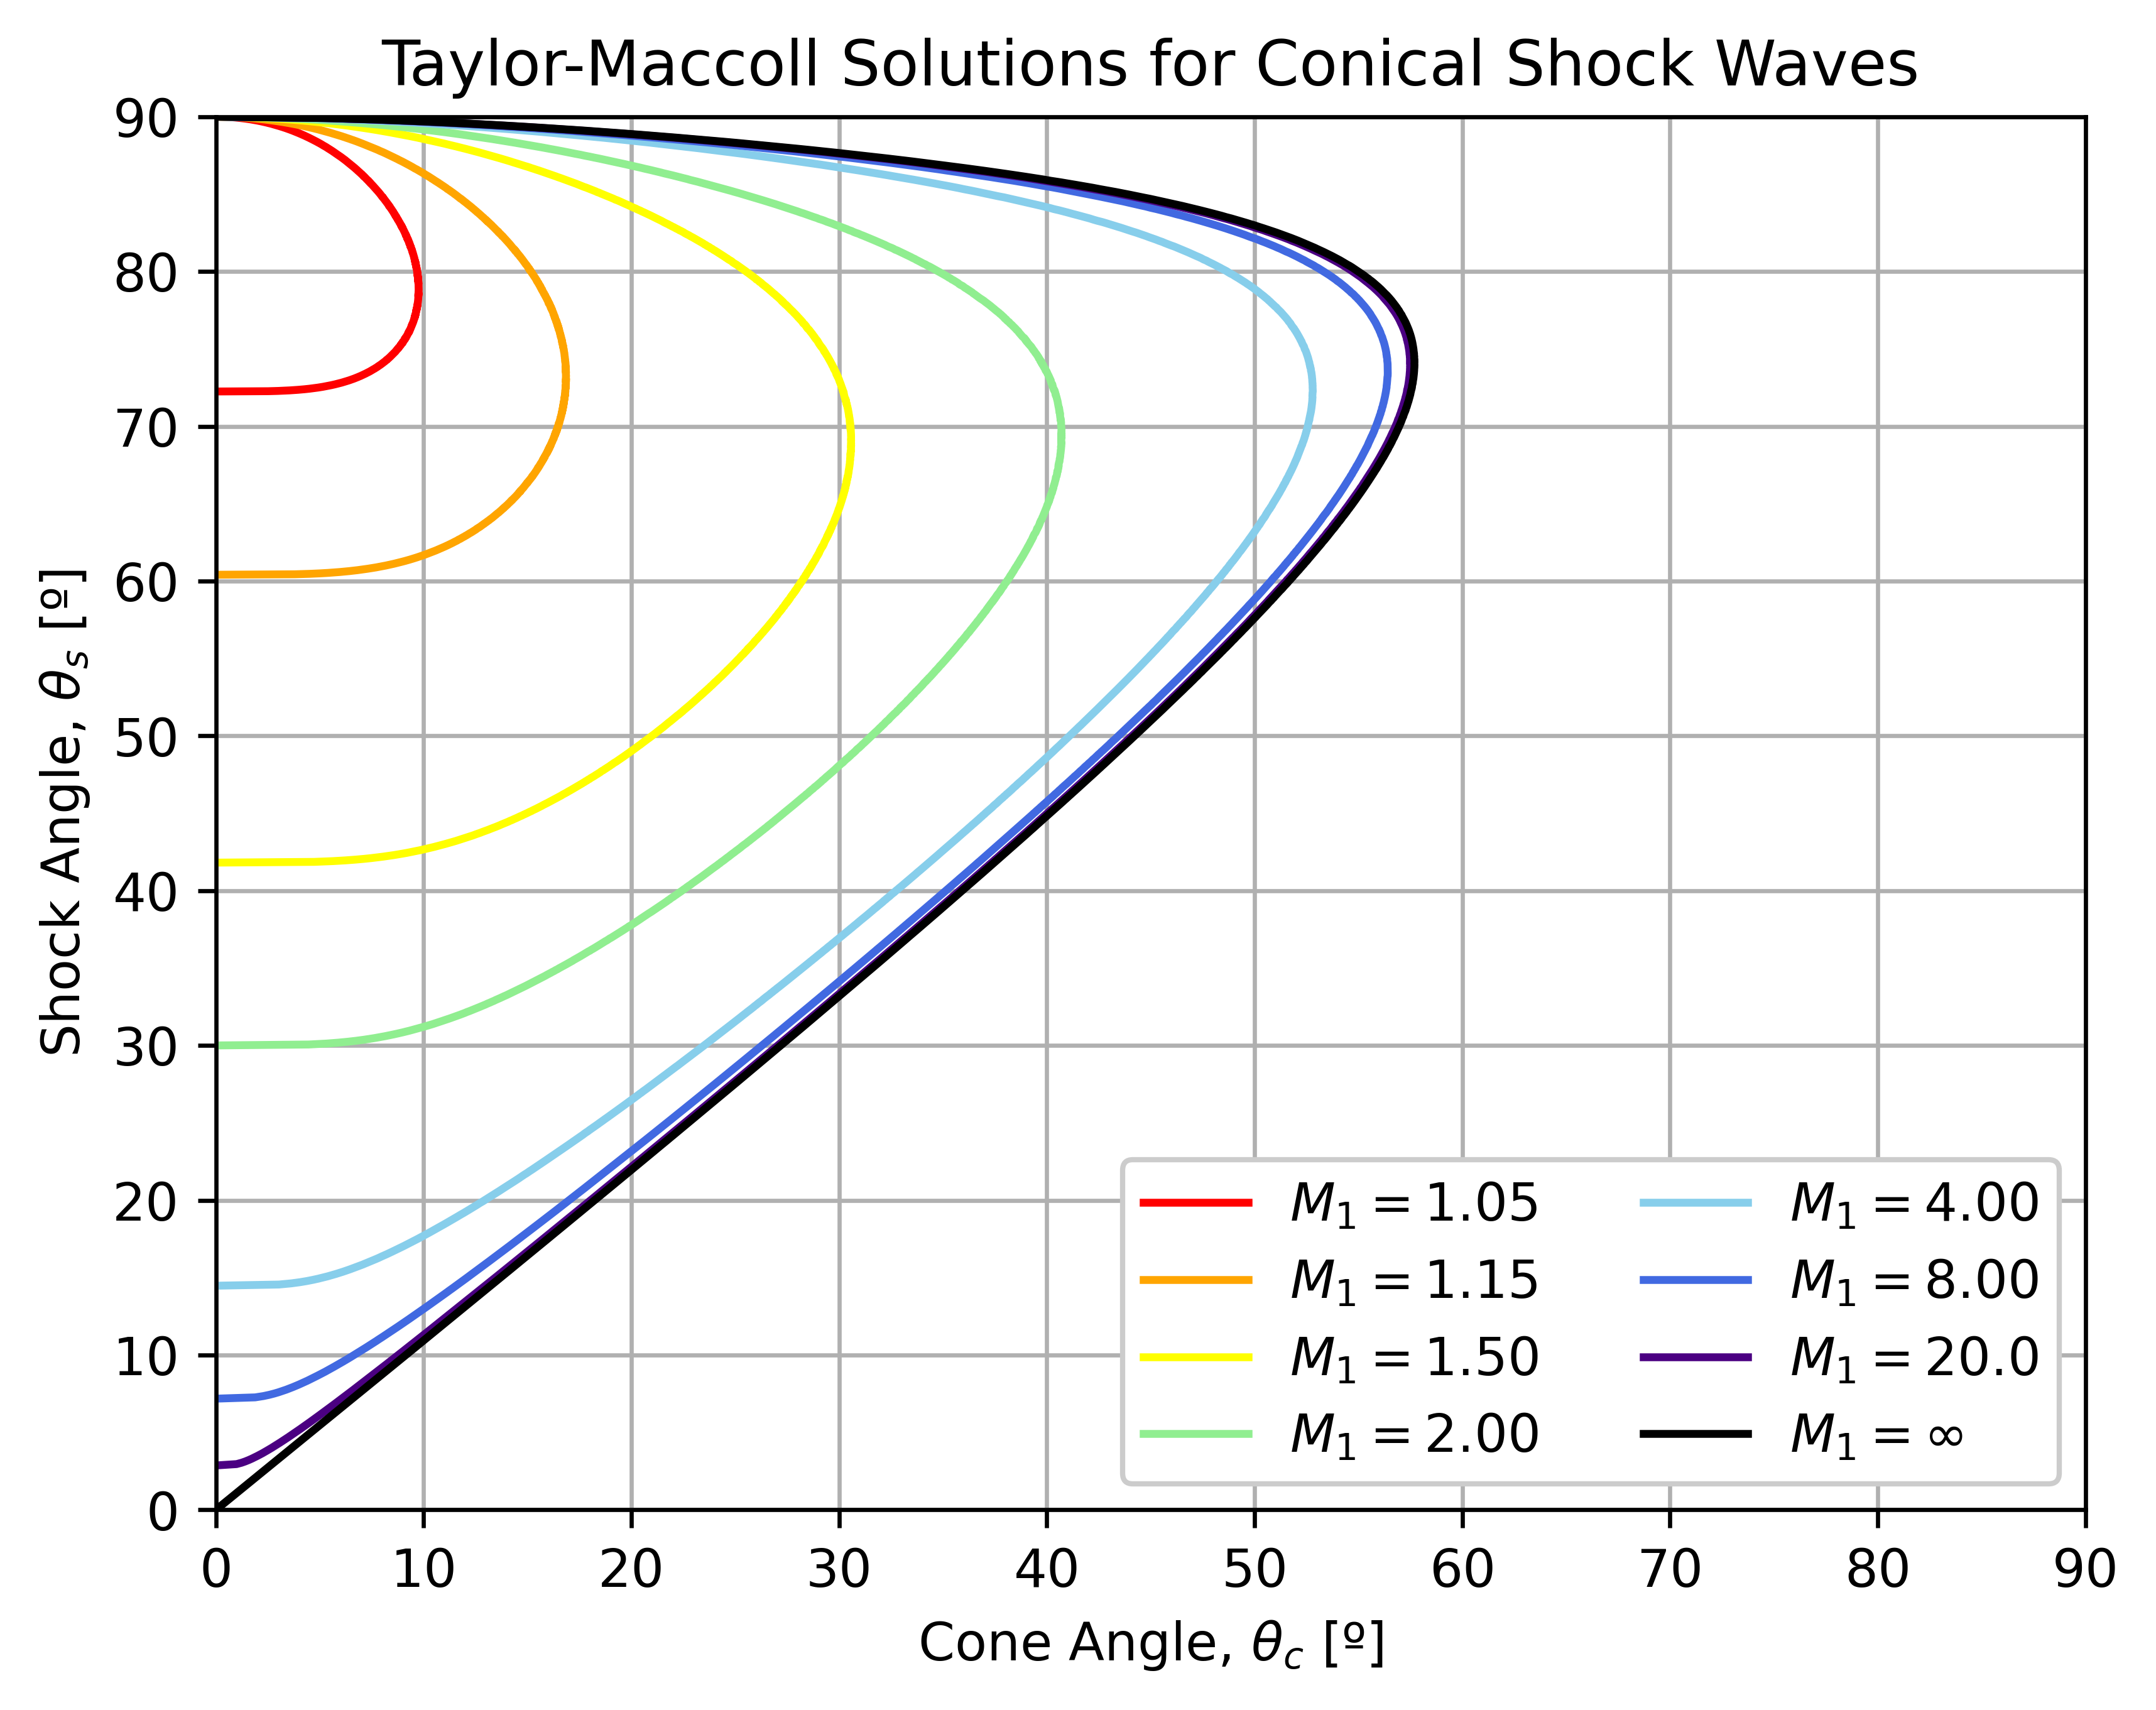

In [50]:
mach = [1.05, 1.15, 1.5, 2.0, 4.0, 8.0, 20.0, 10000.0]
label = [r'$M_1 = 1.05$', r'$M_1 = 1.15$', r'$M_1 = 1.50$', r'$M_1 = 2.00$', r'$M_1 = 4.00$', r'$M_1 = 8.00$', r'$M_1 = 20.0$', r'$M_1 = \infty$']
color = ['red', 'orange', 'yellow', 'lightgreen', 'skyblue', 'royalblue', 'indigo', 'black']

for m in range(0, len(mach)):
    M1 = mach[m]
    gamma = 1.4

    mu = np.arcsin(1/M1)

    theta_s = np.linspace(mu, np.pi/2, 1000)
    theta_c = np.empty_like(theta_s)

    theta_c[0] = 0
    for i in range(1, len(theta_s)):
        theta_c[i] = find_theta_c(theta_s[i], M1, h = -1e-6, tol = 1e-9, gamma = gamma)

    plt.plot(np.rad2deg(theta_c), np.rad2deg(theta_s), label = label[m], color = color[m])

plt.gca().set(xlabel = r'Cone Angle, $\theta_c$ [º]', ylabel = r'Shock Angle, $\theta_s$ [º]', xlim = (0, 90), ylim = (0, 90), title = 'Taylor-Maccoll Solutions for Various Free-Stream Mach Number')
plt.grid(); plt.legend(ncol = 2, loc = 'lower right', framealpha = 1.0)
plt.show()